# Q2D Cross-Section Impedance of a Coplanar Waveguide

This notebook demonstrates how to extract the characteristic impedance
:math:`Z_0` of a coplanar waveguide (CPW) cross-section using the
Ansys 2D Extractor (Q2D) quasi-static field solver via PyAEDT.

The Q2D solver computes per-unit-length RLGC parameters from the
cross-sectional geometry, from which the characteristic impedance
can be obtained as a function of frequency.  We compare the
full-wave Q2D result against the analytical conformal-mapping estimate
from :func:`~qpdk.models.cpw.cpw_parameters`.

**Prerequisites:**
- Ansys Electronics Desktop installed (requires license)
- Install hfss extras: `uv sync --extra hfss` or `pip install qpdk[hfss]`

**References:**
- PyAEDT Documentation: https://aedt.docs.pyansys.com/
- Q2D Coplanar Waveguide Example: https://examples.aedt.docs.pyansys.com/version/dev/examples/high_frequency/radiofrequency_mmwave/coplanar_waveguide.html
- Simons, *Coplanar Waveguide Circuits, Components, and Systems* {cite:p}`simonsCoplanarWaveguideCircuits2001`

## Setup and Imports

In [1]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing quantum-rf-pdk...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[models] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
    ])

In [2]:
import os
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from ansys.aedt.core import Q2d, settings
from IPython.display import Image, display

from qpdk import PDK
from qpdk.config import PATH
from qpdk.models.cpw import cpw_parameters
from qpdk.simulation import Q2D
from qpdk.tech import coplanar_waveguide

PDK.activate()

# CPW dimensions
cpw_width = 10  # µm
cpw_gap = 6  # µm
cross_section = coplanar_waveguide(width=cpw_width, gap=cpw_gap)

# Analytical impedance estimate
ep_eff_analytical, z0_analytical = cpw_parameters(cpw_width, cpw_gap)

print(f"CPW dimensions: width = {cpw_width} µm, gap = {cpw_gap} µm")
print(
    f"Analytical estimate: Z₀ = {z0_analytical:.2f} Ω, ε_eff = {ep_eff_analytical:.4f}"
)

## Initialize Q2D Project

Set up an Ansys 2D Extractor project.  The Q2D solver uses a quasi-static
approach to compute per-unit-length transmission-line parameters from the
2D cross-section.

**Note:** This section requires Ansys Electronics Desktop to be installed
and licensed.

In [4]:
# Configuration for Q2D simulation
Q2D_CONFIG = {
    "sweep_start_ghz": 1.0,  # Sweep from 1 GHz
    "sweep_stop_ghz": 10.0,  # to 10 GHz
    "sweep_step_ghz": 0.1,  # 100 MHz step
}

In [5]:
# Ensure Ansys path is set so PyAEDT can find it
ansys_default_path = "/usr/ansys_inc/v252/AnsysEM"
if "ANSYSEM_ROOT252" not in os.environ and Path(ansys_default_path).exists():
    os.environ["ANSYSEM_ROOT252"] = ansys_default_path

settings.use_grpc_uds = False

# Create temporary directory for project
temp_dir = tempfile.TemporaryDirectory(suffix=".ansys_qpdk")
project_path = Path(temp_dir.name) / "cpw_q2d.aedt"

# Initialize Q2D
q2d = Q2d(
    project=str(project_path),
    design="CPW_Impedance",
    non_graphical=False,
    new_desktop=True,
    version="2025.2",
)

print(f"Q2D project created: {q2d.project_file}")
print(f"Design name: {q2d.design_name}")

PyAEDT INFO: Python version 3.12.13 (main, Mar  3 2026, 14:59:34) [Clang 21.1.4 ].


PyAEDT INFO: PyAEDT version 0.26.2.


PyAEDT INFO: Initializing new Desktop session.


PyAEDT INFO: AEDT version 2025.2.


PyAEDT INFO: New AEDT session is starting on gRPC port 57449.


...

PyAEDT WARNING: Please download and install latest Service Pack to use connect to AEDT in Secure Mode.


PyAEDT INFO: Project cpw_q2d has been created.


PyAEDT INFO: Added design 'CPW_Impedance' of type 2D Extractor.


PyAEDT INFO: AEDT objects correctly read


Q2D project created: /tmp/tmp70dmm41z.ansys_qpdk/cpw_q2d.aedt
Design name: CPW_Impedance


## Build CPW Cross-Section Geometry

Use :meth:`~qpdk.simulation.q3d.Q2D.create_2d_from_cross_section` to automatically
build the CPW geometry (signal conductor, ground planes, substrate) from the
gdsfactory cross-section and QPDK layer stack.

In [6]:

# Create the Q2D wrapper
q2d_sim = Q2D(q2d)

# Create the 2D cross-section geometry
object_names = q2d_sim.create_2d_from_cross_section(cross_section, ground_width=30)

print("Created Q2D geometry:")
for role, name in object_names.items():
    print(f"  {role}: {name}")

2026-04-29 08:42:39.698 | WARNING  | qpdk.simulation.q3d:create_2d_from_cross_section:282 - Setting conductor_thickness to 2.0 um for Q2D stability.


PyAEDT INFO: Materials class has been initialized! Elapsed time: 0m 0sec


PyAEDT INFO: Adding new material to the Project Library: Nb


PyAEDT INFO: Material has been added in Desktop.


PyAEDT INFO: Adding new material to the Project Library: Si


...

PyAEDT INFO: Boundary SignalLine signal has been created.


PyAEDT INFO: Boundary ReferenceGround gnd has been created.


PyAEDT INFO: Mesh class has been initialized! Elapsed time: 0m 0sec


PyAEDT INFO: Mesh class has been initialized! Elapsed time: 0m 0sec


Created Q2D geometry:
  signal: signal
  gnd_left: gnd_left
  gnd_right: gnd_right
  substrate: substrate


### Q2D Cross-Section Geometry
Here is the 2D geometry of the CPW cross-section in Ansys 2D Extractor.

![Q2D geometry](../docs/_static/images/q2d_cpw_impedance_geom.jpg)

PyAEDT INFO: Parsing /tmp/tmp70dmm41z.ansys_qpdk/cpw_q2d.aedt.


PyAEDT INFO: File /tmp/tmp70dmm41z.ansys_qpdk/cpw_q2d.aedt correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: aedt file load time 0.002233743667602539


PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 0sec


PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 0sec


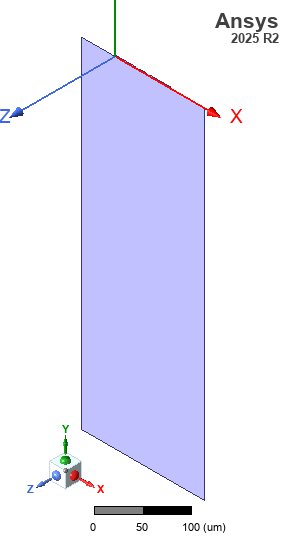

In [7]:
# Ensure Q2D model fits the screen
q2d.modeler.fit_all()

# Save screenshot
img_dir = PATH.repo / "docs" / "_static" / "images"
img_dir.mkdir(parents=True, exist_ok=True)
q2d_img_path = img_dir / "q2d_cpw_impedance_geom.jpg"
q2d.post.export_model_picture(
    full_name=str(q2d_img_path), show_axis=True, show_grid=False, show_ruler=True
)

# Display in notebook
display(Image(filename=str(q2d_img_path)))

## Configure Q2D Analysis

Set up the solution with a frequency sweep from 1 GHz to 10 GHz to compute
the characteristic impedance across the frequency range.

In [8]:
# Create setup
setup = q2d.create_setup(name="Q2DSetup")

# Add frequency sweep
sweep = setup.add_sweep(name="FrequencySweep")
sweep.props["RangeType"] = "LinearStep"
sweep.props["RangeStart"] = f"{Q2D_CONFIG['sweep_start_ghz']}GHz"
sweep.props["RangeStep"] = f"{Q2D_CONFIG['sweep_step_ghz']}GHz"
sweep.props["RangeEnd"] = f"{Q2D_CONFIG['sweep_stop_ghz']}GHz"
sweep.props["Type"] = "Interpolating"
sweep.update()

print("Q2D setup configured:")
print(
    f"  - Sweep range: {Q2D_CONFIG['sweep_start_ghz']} – {Q2D_CONFIG['sweep_stop_ghz']} GHz"
)
print(f"  - Step size: {Q2D_CONFIG['sweep_step_ghz']} GHz")

Q2D setup configured:
  - Sweep range: 1.0 – 10.0 GHz
  - Step size: 0.1 GHz


## Run Simulation

Execute the Q2D analysis.

In [9]:
print("Starting Q2D analysis...")
print("(This may take a few minutes)")

# Save project before analysis
q2d.save_project()

# Run the analysis
start_time = time.time()
success = q2d.analyze(cores=4)
elapsed = time.time() - start_time

if not success:
    raise RuntimeError("Q2D simulation failed. Check the AEDT log for details.")
else:
    print(f"Analysis completed in {elapsed:.1f} seconds")

Starting Q2D analysis...
(This may take a few minutes)
PyAEDT INFO: Project cpw_q2d Saved correctly


PyAEDT INFO: Project cpw_q2d Saved correctly


PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/2D Extractor correctly changed.


PyAEDT INFO: Solving all design setups. Analysis started...


PyAEDT INFO: Design setup None solved correctly in 0.0h 0.0m 8.0s


PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/2D Extractor correctly changed.


Analysis completed in 8.4 seconds


## Extract and Plot Impedance

Extract the characteristic impedance :math:`Z_0` from Q2D and compare it
with the analytical conformal-mapping estimate.  The analytical value is
shown as a horizontal dashed line.

PyAEDT WARNING: No report category provided. Automatically identified Matrix


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec


~/dev/quantum-rf-pdk/.venv/lib/python3.12/site-packages/ansys/aedt/core/visualization/post/solution_data.py:648: UserWarning: Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.
  warnings.warn("Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.")


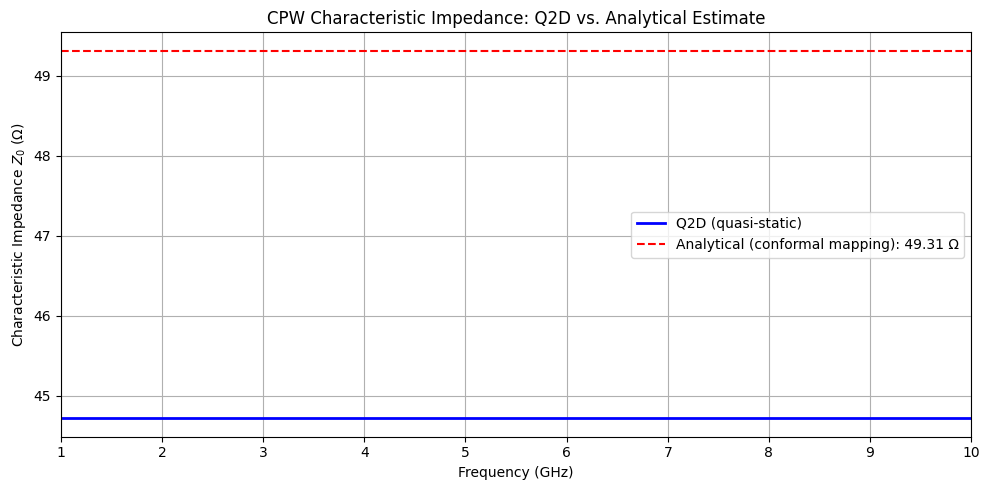


=== Impedance Comparison ===
---------------------------------------------
Analytical Z₀ (conformal mapping): 49.31 Ω
Q2D Z₀ (mean over frequency):      44.72 Ω
Relative difference:                -9.32%
---------------------------------------------


In [10]:
# Extract Z0 from Q2D
data = q2d.post.get_solution_data(
    expressions="Z0(signal,signal)",
    context="Original",
    setup_sweep_name="Q2DSetup : FrequencySweep",
)

frequencies_ghz = np.array(data.primary_sweep_values)
z0_q2d = np.array(data.data_real())

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

# Q2D result
ax.plot(frequencies_ghz, z0_q2d, "b-", linewidth=2, label="Q2D (quasi-static)")

# Analytical estimate as a horizontal line
ax.axhline(
    y=z0_analytical,
    color="r",
    linestyle="--",
    linewidth=1.5,
    label=f"Analytical (conformal mapping): {z0_analytical:.2f} Ω",
)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Characteristic Impedance $Z_0$ (Ω)")
ax.set_title("CPW Characteristic Impedance: Q2D vs. Analytical Estimate")
ax.legend()
ax.grid(True)
ax.set_xlim(Q2D_CONFIG["sweep_start_ghz"], Q2D_CONFIG["sweep_stop_ghz"])

plt.tight_layout()
plt.show()

# --- Numerical comparison ---
z0_mean_q2d = np.mean(z0_q2d)
relative_diff = (z0_mean_q2d - z0_analytical) / z0_analytical * 100

print("\n=== Impedance Comparison ===")
print("-" * 45)
print(f"Analytical Z₀ (conformal mapping): {z0_analytical:.2f} Ω")
print(f"Q2D Z₀ (mean over frequency):      {z0_mean_q2d:.2f} Ω")
print(f"Relative difference:                {relative_diff:+.2f}%")
print("-" * 45)

## Cleanup

Close the Q2D session and clean up temporary files.

In [11]:
# Save and close
q2d.save_project()
# q2d.release_desktop()  # Uncomment to close the AEDT desktop session
time.sleep(2)

# Clean up temp directory
temp_dir.cleanup()
print("Q2D session closed and temporary files cleaned up")

PyAEDT INFO: Project cpw_q2d Saved correctly


Q2D session closed and temporary files cleaned up


## Summary

This notebook demonstrated:

1. **Cross-Section Definition**: Using QPDK's `coplanar_waveguide` cross-section
   to define CPW geometry (10 µm width, 6 µm gap)

2. **Q2D Setup**: Initializing Ansys 2D Extractor via PyAEDT and building the
   cross-sectional geometry using
   :meth:`~qpdk.simulation.q3d.Q2D.create_2d_from_cross_section`

3. **Impedance Extraction**: Running the Q2D quasi-static solver to compute
   :math:`Z_0` as a function of frequency from 1 to 10 GHz

4. **Analytical Validation**: Comparing the Q2D result with the conformal-mapping
   analytical estimate from :func:`~qpdk.models.cpw.cpw_parameters`

**Key Points for CPW Design:**
- The Q2D solver gives frequency-dependent impedance including dispersion effects
- The analytical conformal-mapping model provides a good quasi-static estimate
- For superconducting CPWs (PEC conductors), the impedance is nearly
  frequency-independent in the low-GHz range
- No backplate metallisation is used, matching typical superconducting fabrication

**Next Steps:**
- Vary CPW dimensions to study impedance sensitivity
- Compare with HFSS 3D driven-modal simulations
- Study the effect of conductor thickness on impedance


## References

```{bibliography}
:filter: docname in docnames
```